# 1. Data Preparation 

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("demand.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   10-Piece Set sold units  27 non-null     str  
 1   Time in month            27 non-null     int64
 2   10-Piece Set sale price  27 non-null     str  
 3   Feb                      27 non-null     int64
 4   Mar                      27 non-null     int64
 5   Apr                      27 non-null     int64
 6   May                      27 non-null     int64
 7   Jun                      27 non-null     int64
 8   Jul                      27 non-null     int64
 9   Aug                      27 non-null     int64
 10  Oct                      27 non-null     int64
 11  Nov                      27 non-null     int64
 12  Dec                      27 non-null     int64
dtypes: int64(11), str(2)
memory usage: 3.2 KB


In [4]:
df["10-Piece Set sale price"] = df["10-Piece Set sale price"].str.replace("$", "").astype("float")
df["10-Piece Set sold units"] = df["10-Piece Set sold units"].str.replace(",", "").astype("int")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   10-Piece Set sold units  27 non-null     int64  
 1   Time in month            27 non-null     int64  
 2   10-Piece Set sale price  27 non-null     float64
 3   Feb                      27 non-null     int64  
 4   Mar                      27 non-null     int64  
 5   Apr                      27 non-null     int64  
 6   May                      27 non-null     int64  
 7   Jun                      27 non-null     int64  
 8   Jul                      27 non-null     int64  
 9   Aug                      27 non-null     int64  
 10  Oct                      27 non-null     int64  
 11  Nov                      27 non-null     int64  
 12  Dec                      27 non-null     int64  
dtypes: float64(1), int64(12)
memory usage: 2.9 KB


# 2. Fourier Series and a Dummmy variable

In [6]:
# Fourier Series
t = df["Time in month"]
P = 12

df["sin_1"] = np.sin(2 * np.pi * 1 * t / P)
df["cos_1"] = np.cos(2 * np.pi * 1 * t / P)
df['sin_2'] = np.sin(2 * np.pi * 2 * t / P)
df['cos_2'] = np.cos(2 * np.pi * 2 * t / P)

# dummy variable (peak season: 1, normal season: 0, valley season:-1)
df["dummy_1"] = pd.Series(data=[
	-1, -1, 0, 0, 0, -1, -1, 0, 1, 1, 1, 0, -1, -1, 0, 0, 0, -1, -1, 0, 1, 1, 1, 0, -1, -1, 0
])

# 3. ML
## 3.1. Test - Train Split

In [7]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
x = df.drop(columns=["10-Piece Set sold units", "sin_1", "cos_1", 'sin_2', 'cos_2'])
# x = df[["Time in month", "10-Piece Set sale price", "sin_1", "cos_1", "sin_2", "cos_2"]]
# x = df[["Time in month", "10-Piece Set sale price", "dummy_1"]]
y = df["10-Piece Set sold units"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=3, shuffle=False)

## 3.2. Pipe

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.feature_selection import SelectKBest, mutual_info_regression

alphas = np.logspace(-2, 2, 10)

cv = TimeSeriesSplit(n_splits=3, test_size=3)

input_steps=[
	# ("polly", PolynomialFeatures(degree=3, include_bias=False, interaction_only=True)),
	
	("scaler", StandardScaler()),
	# ('select_top_3', SelectKBest(score_func=mutual_info_regression, k=4)),
	("model", LassoCV(
		alphas=alphas, cv=cv)),
	# ("model", LinearRegression())
]

pipe = Pipeline(input_steps)

## 3.3. Train

In [9]:
pipe.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+02])
,fit_intercept,True


## 3.4. Selected Features

In [10]:
# selected_indices = pipe.named_steps['select_top_3'].get_support()
# selected_columns = x_train.columns[selected_indices]

# print("\nModelin Seçtiği En Güçlü 3 Kategorik Değişken:")
# print(list(selected_columns))

## 3.5. Train R2 Scores

In [11]:
pipe.score(x_train, y_train)

0.9502294304551274

## 3.6. Intercept and coefficients

In [12]:
lasso = pipe.named_steps["model"]
coefficients = lasso.coef_
features = pipe.named_steps['scaler'].feature_names_in_

coef_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': coefficients
})

coef_df.set_index("Variable", drop=True)

,Coefficient
Variable,
Time in month,102.731527
10-Piece Set sale price,-245.681800
Feb,38.436457
Mar,29.114520
Apr,37.173605
May,0.458259
Jun,-36.269958
Jul,-15.358889
Aug,2.801206


## 3.7. Predictions (Test and Train)

In [13]:
y_pred = pipe.predict(x_test)
y_pred_train = pipe.predict(x_train)

# 4. Accuracy
## 4.1 Train Actual and Predictions

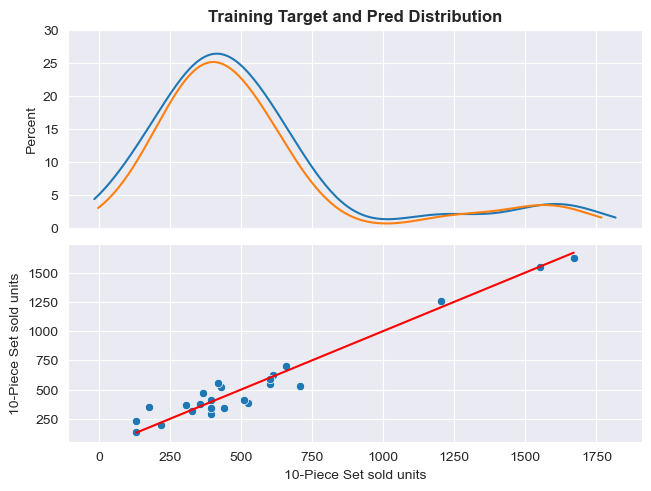

In [14]:
## Test and pred graphs
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

fig, ax = plt.subplots(nrows=2, ncols=1, layout="constrained", sharex=True)

lines = [y_train, y_pred_train]
colors = ["red", "blue"]

for i in range(2):
	sns.histplot(x=lines[i], ax=ax[0], lw=0, stat="percent", kde=True, kde_kws={"bw_adjust": 0.7, "cut": True, "cumulative": False}, line_kws={"color": colors[i]}, alpha=0)
	ax[0].set_ylim(0, 30)
ax[0].set_title("Training Target and Pred Distribution", fontweight="bold")

sns.scatterplot(x=y_train, y=y_pred_train, ax=ax[1])
sns.lineplot(x=y_train, y=y_train, color="red", ax=ax[1])

plt.savefig("train_target_pred_dist.png");

## 4.2 Test R2 Score

In [15]:
pipe.score(x_test, y_test)

0.5489778233375994

## 4.3. Residuals

In [16]:
residuals_test = y_test - y_pred
residuals_test_mean = residuals_test.mean()
residuals_test_std = residuals_test.std()

residuals_train = y_train - y_pred_train
residuals_train_mean = residuals_train.mean()
residuals_train_std = residuals_train.std()

print("Residuals (test) mean:", np.round(residuals_test_mean, 2))
print("Residuals (test) std:", np.round(residuals_test_std, 2))
print("Residuals (train) mean:", np.round(residuals_train_mean, 2))
print("Residuals (train) std:", np.round(residuals_train_std, 2))

Residuals (test) mean: -38.84
Residuals (test) std: 166.17
Residuals (train) mean: 0.0
Residuals (train) std: 88.7


### 4.3.1. Training Data Residuals 

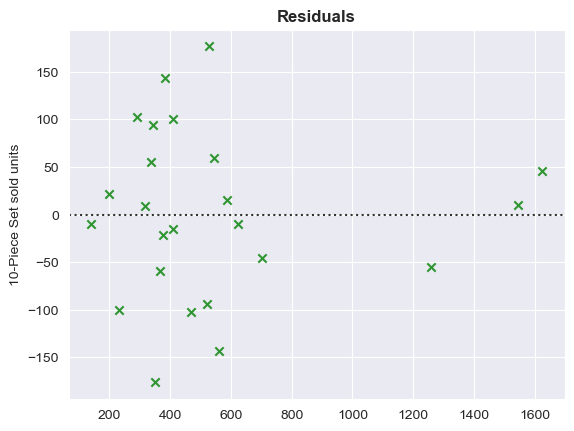

In [17]:
sns.residplot(x=y_pred_train, y=residuals_train, color="green", scatter_kws={"marker": "x"})
plt.title("Residuals", fontweight=650)
plt.savefig("residuals.png")

### 4.3.2. Training Data Residuals - Normality

Skewness is: 2.7596181324392677e-05
Kurtosis is: -0.3295592269287053


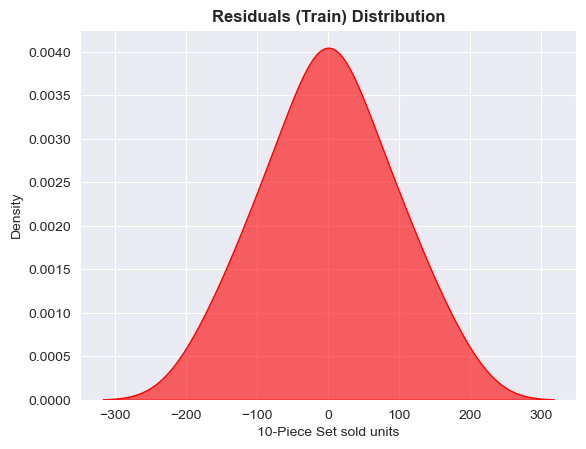

In [18]:
## Residual validation
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(x=residuals_train, fill=True, color="red", bw_adjust=1, label="Test", alpha=0.6)
plt.title("Residuals (Train) Distribution", fontweight=650)
skewness = residuals_train.skew()
kurtosis = residuals_train.kurt()
print("Skewness is:", skewness)
print("Kurtosis is:", kurtosis)
plt.savefig("residuals_train_distribution.png")

### 4.3.3. Training Data Residuals - Linearity

In [19]:
import statsmodels.api as sm

x_temp = np.column_stack((y_pred_train, y_pred_train**2))
x_temp = sm.add_constant(x_temp)

model_temp = sm.OLS(residuals_train, x_temp).fit()

p_value = model_temp.pvalues.iloc[2]

print(f"p value (y_pred^2): {p_value:.4f}")

if p_value < 0.05:
    print("Model is not linear. There is some non-linear relation between y_pred^2 and residuals.")
else:
    print("Model is linear.")

p value (y_pred^2): 0.6156
Model is linear.


### 4.3.4. Training Data Residuals - Independence

In [20]:
from statsmodels.stats.stattools import durbin_watson
db = durbin_watson(residuals_train)
print("Durbin Watson is ", db)
p_value = 1 - db / 2
print("Independence p_value is", p_value)

if -0.25 < p_value < 0.25:
	print("Model residuals are independent.")
else:
	print("Model residuals are DEPENDENT.")

Durbin Watson is  1.84878921974064
Independence p_value is 0.07560539012968004
Model residuals are independent.


### 4.3.5. Training Data Residuals - Equal Variance

In [21]:
from statsmodels.stats.diagnostic import het_breuschpagan
x_train = sm.add_constant(x_train)
bp_test = het_breuschpagan(residuals_train, x_train)
p_value = bp_test[1]
print("Het Breuschpagan p value is", p_value)

if p_value > 0.05:
	print("Homoscedasticity, OK!")
else:
	print("HETEROSCEDASTICITY, PROBLEM!, log conversion is needed.")

Het Breuschpagan p value is 0.03113018242218006
HETEROSCEDASTICITY, PROBLEM!, log conversion is needed.


# 5. Scores (MAE, WMAP)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
MAE = mean_absolute_error(y_test, y_pred)
print(MAE)
WMAPE = mean_absolute_percentage_error(y_test, y_pred, sample_weight=y_test)
print(WMAPE)

112.8712174382324
0.08268953658478564
